In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import itertools
from scipy.integrate import ode
from scipy.optimize import minimize 
from tqdm import tqdm
import numpy as np
import scipy

In [93]:

data = pd.read_csv("Folder1-Flow_Cytometry_Data/20250326-iVector_Default Unmixed Worksheet.CSV", index_col=0)

data = data[[
    "All Events Count", "Cell Population Count", "Green+ Count", "mCYRFP1+ Count", "Blue+ Count",
    "GFP-BFP+ Count", "GFP-RFP+ Count", "BFP-RFP+ Count", "All+ Count"
]]
data.columns = ["Events", "Cell Population", "GFP+", "RFP+", "BFP+", "GFP_BFP+", "GFP_RFP+", "BFP_RFP+", "All+"]
data = data[["Reference" not in x for x in data.index]]


TOTAL_DNA_NG = 100
PLATED_CELLS = 5e4
PLASMID_SIZES = {"pV39":5730,
"pV40":5727,
"pV41":5730,
"pV42":5727,
"pV43":6220,
"pV44":6220,
"pV47":6495,
"pV48":6492,
"pV50":6495,
"pV51":6495,
"pV58":6495,
"pV59":6495,
"pV63":6495}


PLASMID_FLUORES = {"pV39":["GFP", "BFP"],
"pV40":["GFP", "BFP"],
"pV41":["GFP", "BFP"],
"pV42":["GFP", "BFP"],
"pV43":["GFP", "BFP"],
"pV44":["GFP", "BFP"],
"pV47":["GFP", "RFP", "BFP"],
"pV48":["GFP", "RFP", "BFP"],
"pV50":["GFP", "RFP", "BFP"],
"pV51":["GFP", "RFP", "BFP"],
"pV58":["GFP", "RFP", "BFP"],
"pV59":["GFP", "RFP", "BFP"],
"pV63":["GFP", "RFP", "BFP"]}


plasmids = np.array(list(PLASMID_SIZES.keys()))
plasmids


def calculate_plasmid_copies_per_cell(mass_ng, plasmid_bp):
    AVOGADRO = 6.022e23
    bp_weight = 660  # g/mol per bp
    mass_g = mass_ng * 1e-9
    moles = mass_g / (plasmid_bp * bp_weight)
    return (moles * AVOGADRO) / PLATED_CELLS


data = data[np.sum([[y in x for y in plasmids] for x in data.index], axis = 1) > 0]
plas_id = [[y in x for y in plasmids] for x in data.index]
plas_id = [plasmids[x][0] for x in plas_id]

data["Plasmid Size (bp)"] = [PLASMID_SIZES[x] for x in plas_id]
data["# Plasmids per Cell"] = [calculate_plasmid_copies_per_cell(TOTAL_DNA_NG, x) for x in data["Plasmid Size (bp)"]]
data["Fluores on Plasmid"] = [",".join(PLASMID_FLUORES[x]) for x in plas_id]
data
data["GFP+"] = data["GFP+"]/data["Cell Population"]
data["RFP+"] = data["RFP+"]/data["Cell Population"]
data["BFP+"] = data["BFP+"]/data["Cell Population"]

data["GFP_BFP+"] = data["GFP_BFP+"]/data["Cell Population"]
data["GFP_RFP+"] = data["GFP_RFP+"]/data["Cell Population"]
data["BFP_RFP+"] = data["BFP_RFP+"]/data["Cell Population"]
data["All+"] = data["All+"]/data["Cell Population"]
# data


In [94]:
plas_id = []
for idx in data.index:
    match = [p for p in plasmids if p in idx]
    plas_id.append(match[0] if match else None)

data["Plasmid ID"] = plas_id
data["Plasmid Size (bp)"] = [PLASMID_SIZES[x] for x in plas_id]

effective_ng = [60 if pid in ["pV58", "pV63"] else TOTAL_DNA_NG for pid in plas_id]
data["# Plasmids per Cell"] = [
    calculate_plasmid_copies_per_cell(mass, size)
    for mass, size in zip(effective_ng, data["Plasmid Size (bp)"])
]

data["Fluores on Plasmid"] = [",".join(PLASMID_FLUORES[x]) for x in plas_id]


In [95]:
## this function is taken from the UQ-Bio 2024 Summer School Github https://github.com/MunskyGroup/uqbio2024

def build_inf_gen(S, W, states, pars, t=0):
    """ Build the infinitesimal generator matrix for a continuous time Markov chain.
    S: Stoichiometry matrix
    W: Propensity vector function
    states: list of states in FSP approximation
    t: time
    """
    # Determie the number of species, states and reactions
    nSpecies, nStates = states.shape
    nReactions = S.shape[1]
    # Compute the propensity functions for all states.
    propensities = W(states, t, pars)
    # Step through each reaction
    infGens = []
    infGen = np.zeros((nStates+1,nStates+1))
    sink = np.zeros(nStates)
    for mu in range(nReactions):
        # Compute flow of probability out of all states due to reaction mu
        infGens.append(-np.diag(propensities[mu,:]))
        for i in range(nStates):
            # Compute the states after the reaction mu
            newState = (states[:,i] + S[:,mu]).reshape(-1,1) 
            # Check if the state is non-negative
            if np.all(newState >= 0):
                # Find the index of the state
                try:
                    j = np.where((states == newState).all(axis=0))[0][0]
                    infGens[mu][j,i] += propensities[mu,i]
                except:
                    sink[i] += propensities[mu,i]
        # Add the current reaction to the infinitesimal generator
        infGen[:nStates,:nStates] += infGens[mu]
    # Add the sink as the final row of the infinitesimal generator
    infGen[nStates,:nStates] = sink
    return infGens, sink, infGen



In [96]:
def experiment_pred(x0, params):

    max_plasmids = 8
    S = np.array([[1]])  # Stoichiometry: one plasmid enters

    # Create state space for 0 to max_plasmids plasmids inside
    states = np.array(list(itertools.product(range(max_plasmids + 1),))).T

    # Constant rate of plasmid entry based on initial external plasmid pool
    entry_rate = params[0] * x0

    # Parameter dictionary for generator construction
    pars = {'kcell_entry1': entry_rate}

    # Define transition rates for all states (same rate regardless of current state)
    def W_linear(states, t, pars):
        nStates = states.shape[1]
        W = np.zeros((1, nStates))
        W[0, :] = pars['kcell_entry1']
        return W

    # Construct generator matrix for FSP
    infGens, sink, infGenTotal = build_inf_gen(S, W_linear, states, pars)

    # Initial state: 0 plasmids inside
    x0_state = np.zeros(1, dtype=int)
    idx0 = np.where([(states[:, i] == x0_state).all() for i in range(states.shape[1])])[0]
    P0 = np.zeros(infGenTotal.shape[1])
    P0[idx0] = 1

    # Simulate dynamics over 4 hours
    tspan = np.linspace(0, 4, 100)

    def FSPrhs(t, P): return infGenTotal @ P
    def jac(t, P): return infGenTotal

    solver = ode(FSPrhs, jac=jac).set_integrator('vode', method='bdf')
    solver.set_initial_value(P0)

    P_approach1 = np.zeros((len(tspan), len(P0)))
    P_approach1[0, :] = P0
    for i in range(1, len(tspan)):
        P_approach1[i, :] = solver.integrate(tspan[i])

    # Final state probabilities
    P_final = P_approach1[-1, :]

    # Compute GFP+ probability (i.e., >0 plasmids)
    positive_prob = np.sum(P_final[:-1][states[0, :] > 0])

    return positive_prob


In [97]:
fits = pd.read_csv("Folder2-Model_Parameter_Fits/all_fit_output.csv", index_col = 0)
estimate = fits.iloc[0,2]




In [98]:
pV39 = data[["pV39" in x for x in data.index]].iloc[:,2:9]
pV40 = data[["pV40" in x for x in data.index]].iloc[:,2:9]
pV41 = data[["pV41" in x for x in data.index]].iloc[:,2:9]
pV42 = data[["pV42" in x for x in data.index]].iloc[:,2:9]
pV43 = data[["pV43" in x for x in data.index]].iloc[:,2:9]
pV44 = data[["pV44" in x for x in data.index]].iloc[:,2:9]
pV47 = data[["pV47" in x for x in data.index]].iloc[:,2:9]
pV48 = data[["pV48" in x for x in data.index]].iloc[:,2:9]
pV50 = data[["pV50" in x for x in data.index]].iloc[:,2:9]
pV51 = data[["pV51" in x for x in data.index]].iloc[:,2:9]
pV58 = data[["pV58" in x for x in data.index]].iloc[:,2:9]
pV59 = data[["pV59" in x for x in data.index]].iloc[:,2:9]
pV63 = data[["pV63" in x for x in data.index]].iloc[:,2:9]





In [99]:

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV39"])
pV39_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV40"])
pV40_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV41"])
pV41_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV42"])
pV42_pred = experiment_pred(x0, [estimate])


x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV43"])
pV43_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV44"])
pV44_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV47"])
pV47_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV48"])
pV48_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV50"])
pV50_pred = experiment_pred(x0, [estimate])


x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV51"])
pV51_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV58"])
pV58_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV59"])
pV59_pred = experiment_pred(x0, [estimate])

x0 = calculate_plasmid_copies_per_cell(TOTAL_DNA_NG,PLASMID_SIZES["pV63"])
pV63_pred = experiment_pred(x0, [estimate])

In [100]:
data_plot = [pV39,
            pV40,
            pV41,
            pV42,
            pV43,
            pV44,
            pV47,
            pV48,
            pV50,
            pV51,
            pV58,
            pV59,
            pV63 ]





In [101]:
n_cell_list = [data[["pV39" in x for x in data.index]].iloc[:,1],
data[["pV40" in x for x in data.index]].iloc[:,1],
data[["pV41" in x for x in data.index]].iloc[:,1],
data[["pV42" in x for x in data.index]].iloc[:,1],
data[["pV43" in x for x in data.index]].iloc[:,1],
data[["pV44" in x for x in data.index]].iloc[:,1],
data[["pV47" in x for x in data.index]].iloc[:,1],
data[["pV48" in x for x in data.index]].iloc[:,1],
data[["pV50" in x for x in data.index]].iloc[:,1],
data[["pV51" in x for x in data.index]].iloc[:,1],
data[["pV58" in x for x in data.index]].iloc[:,1],
data[["pV59" in x for x in data.index]].iloc[:,1],
data[["pV63" in x for x in data.index]].iloc[:,1]]


In [102]:

preds = [pV39_pred,
 pV40_pred,
 pV41_pred,
 pV42_pred,
 pV43_pred,
 pV44_pred,
 pV47_pred,
 pV48_pred,
 pV50_pred,
 pV51_pred,
 pV58_pred,
 pV59_pred,
 pV63_pred]



pred_out = []
i = 0
for plas in plasmids:
    if len(PLASMID_FLUORES[plas]) == 2:
        pred_out.append(np.array([1, 0, 1, 1, 0, 0,0]) * preds[i])
    elif len(PLASMID_FLUORES[plas]) == 3:
        pred_out.append(np.array([1, 1, 1, 1, 1, 1,1]) * preds[i])
    i+=1

from scipy.stats import sem

def get_mean_and_ci(df):
    mean = df.mean(axis=0).values
    ci = 1.96 * sem(df.values, axis=0)
    return mean, ci

data_avg, data_ci = zip(*[get_mean_and_ci(df) for df in data_plot])
data_avg = np.vstack(data_avg)
data_ci = np.vstack(data_ci)


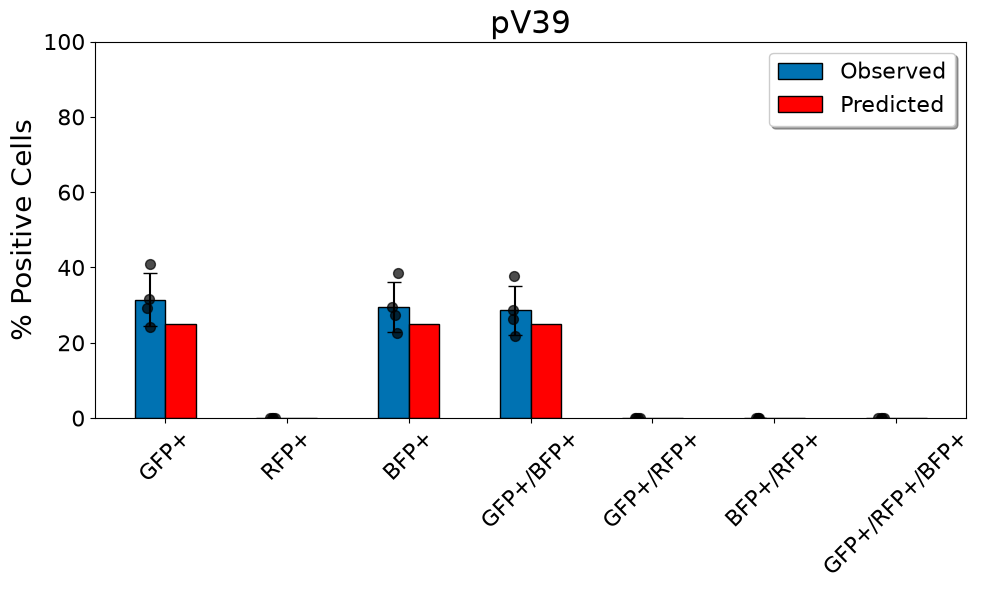

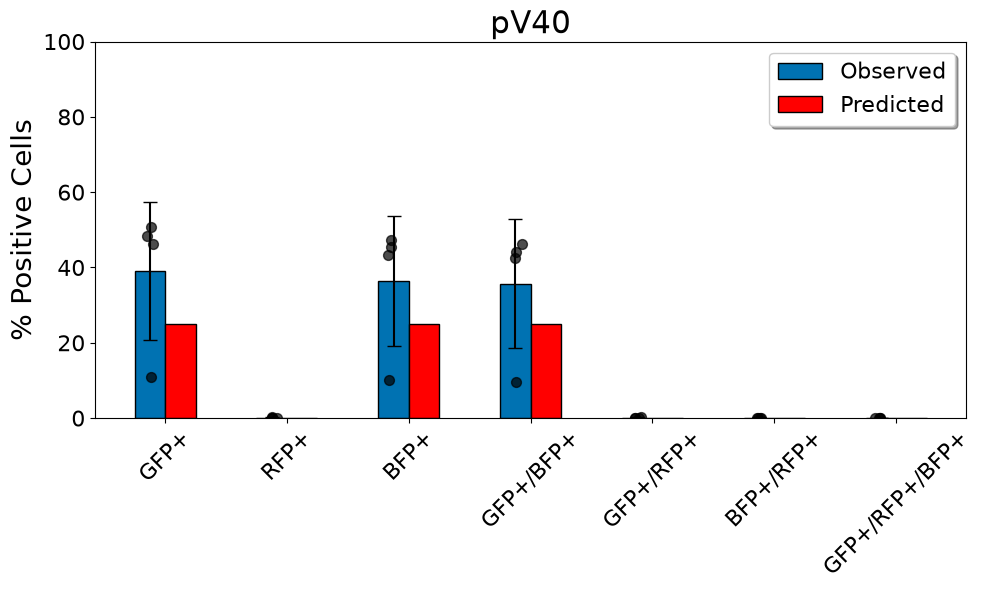

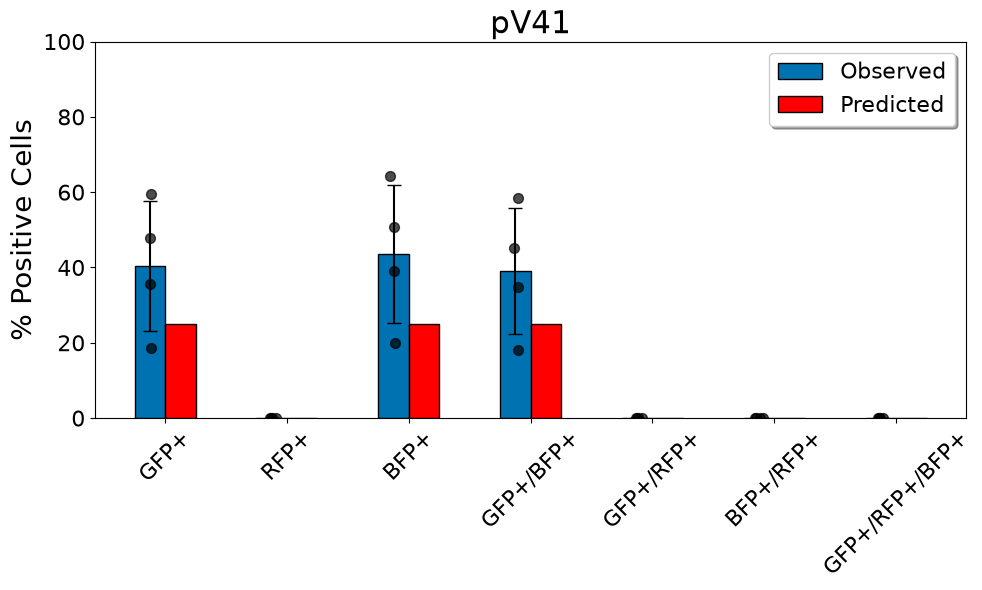

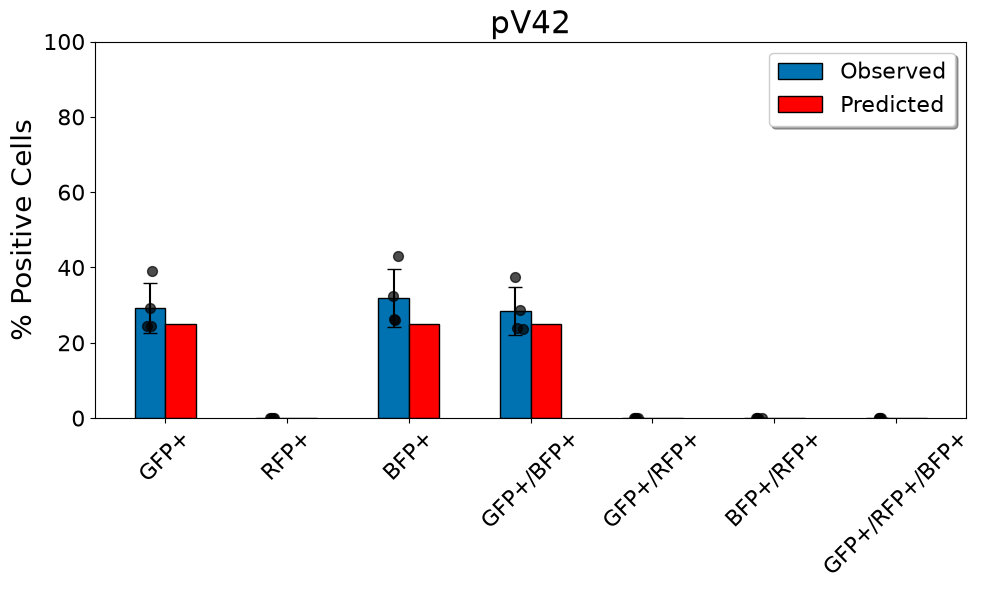

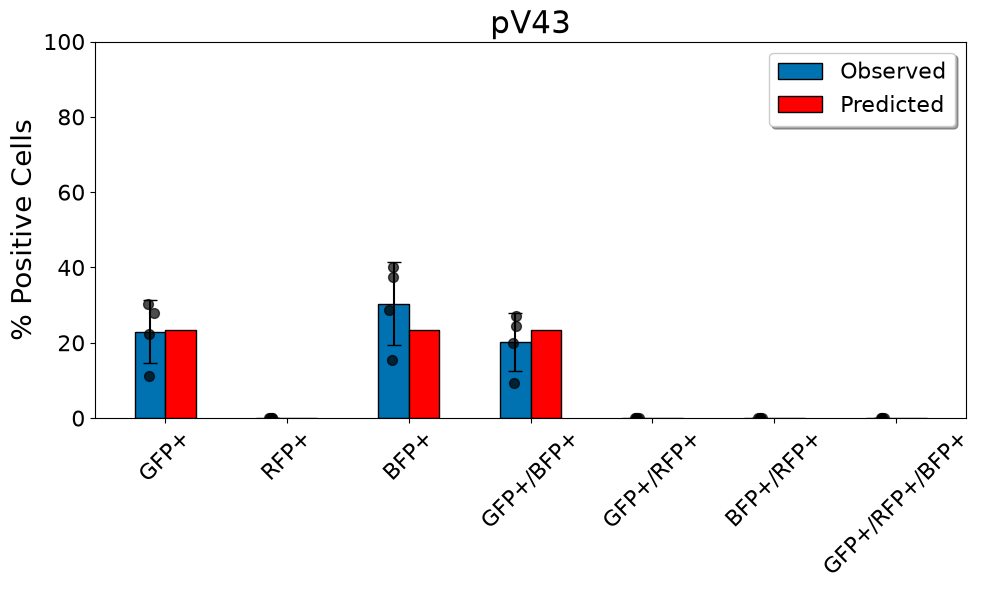

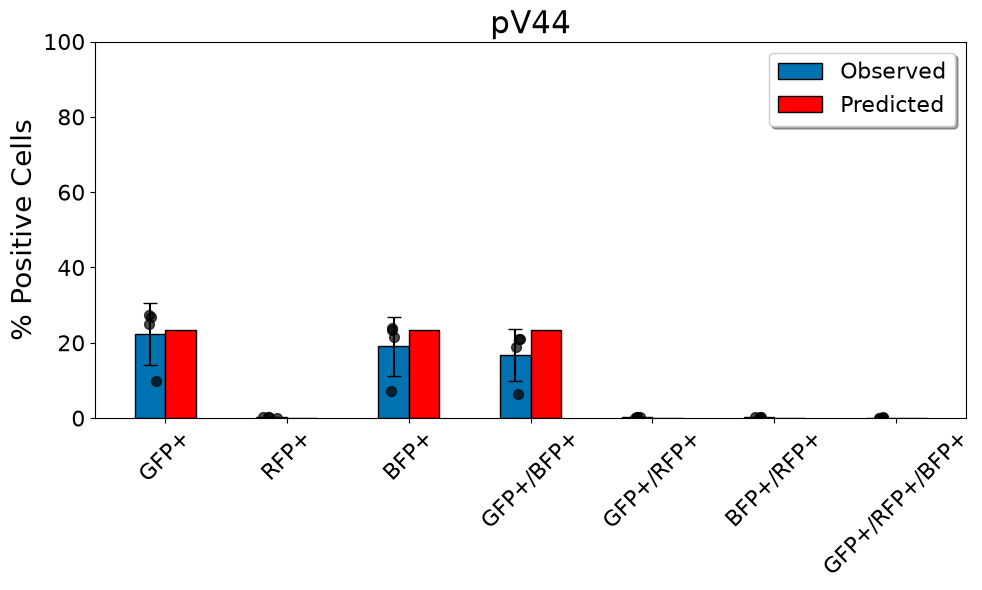

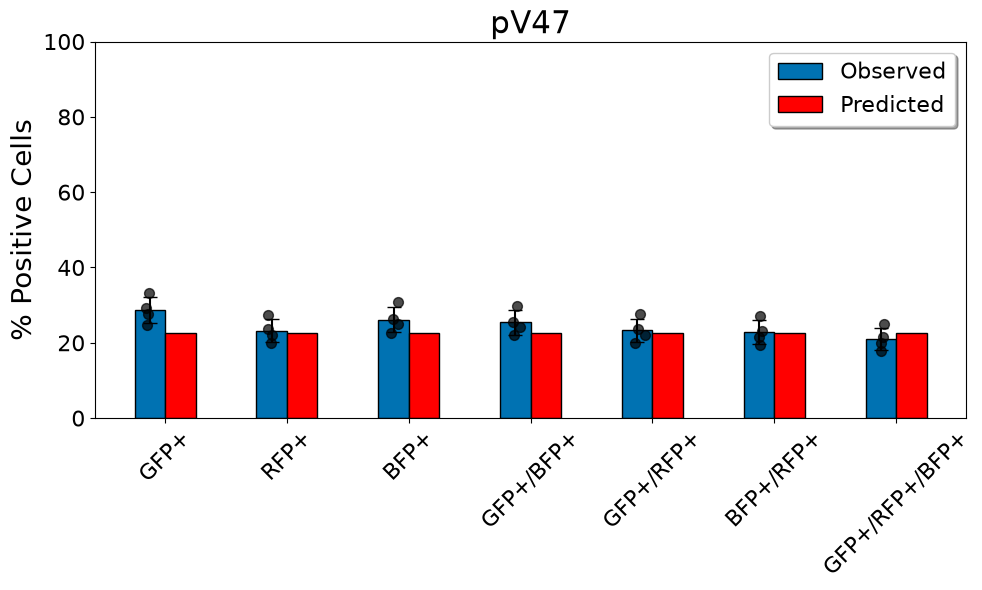

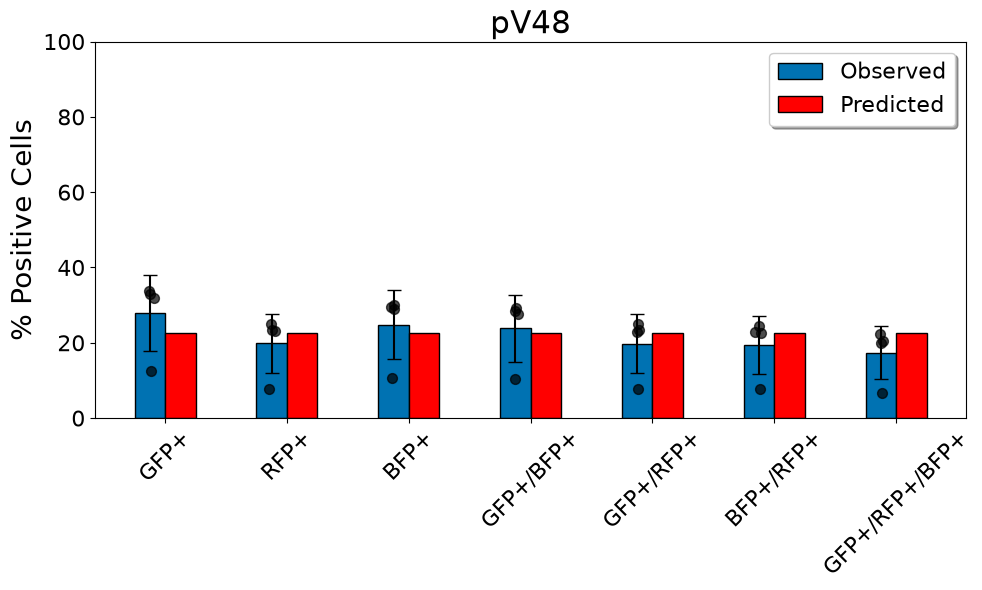

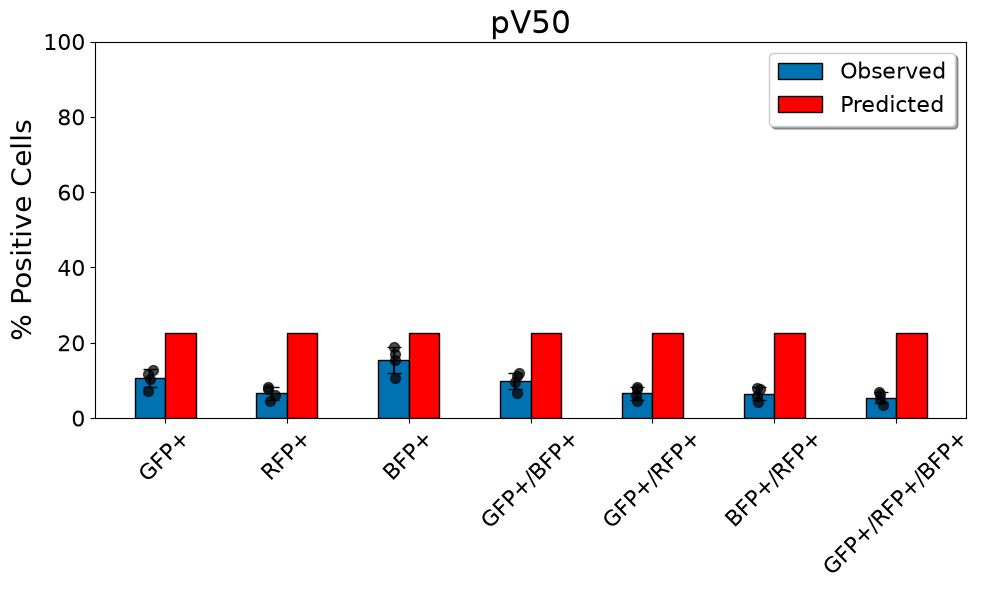

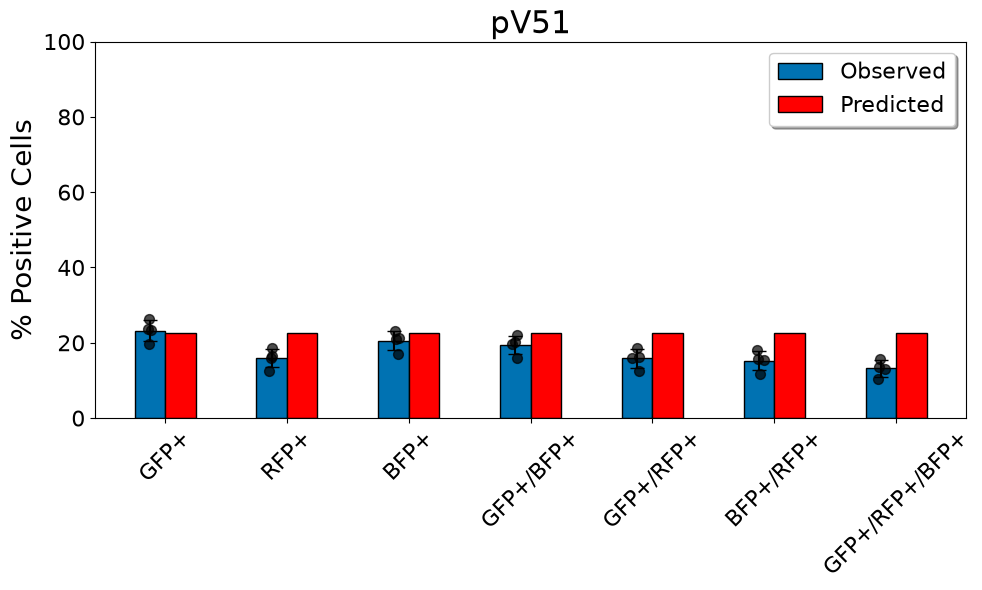

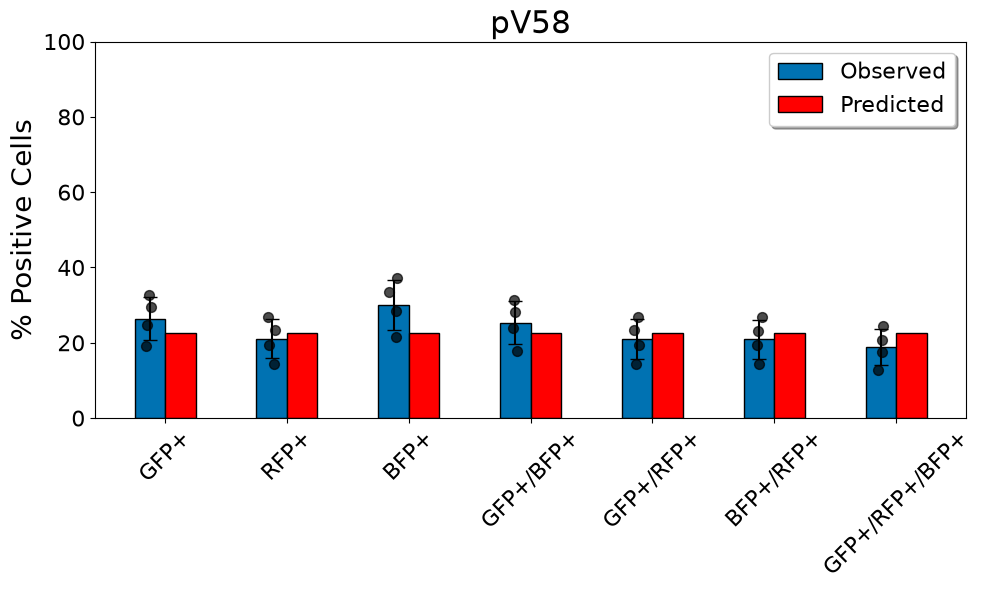

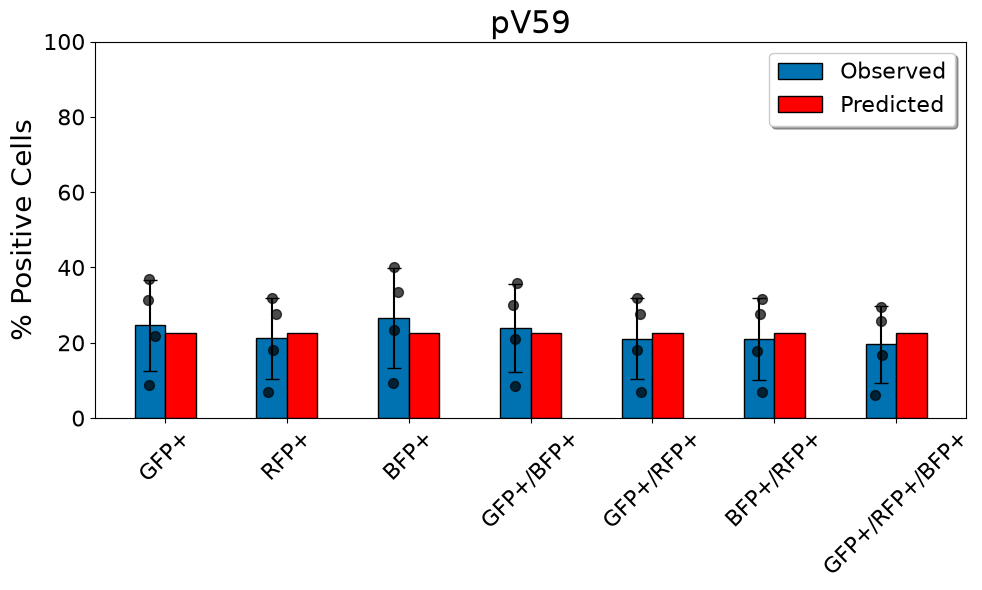

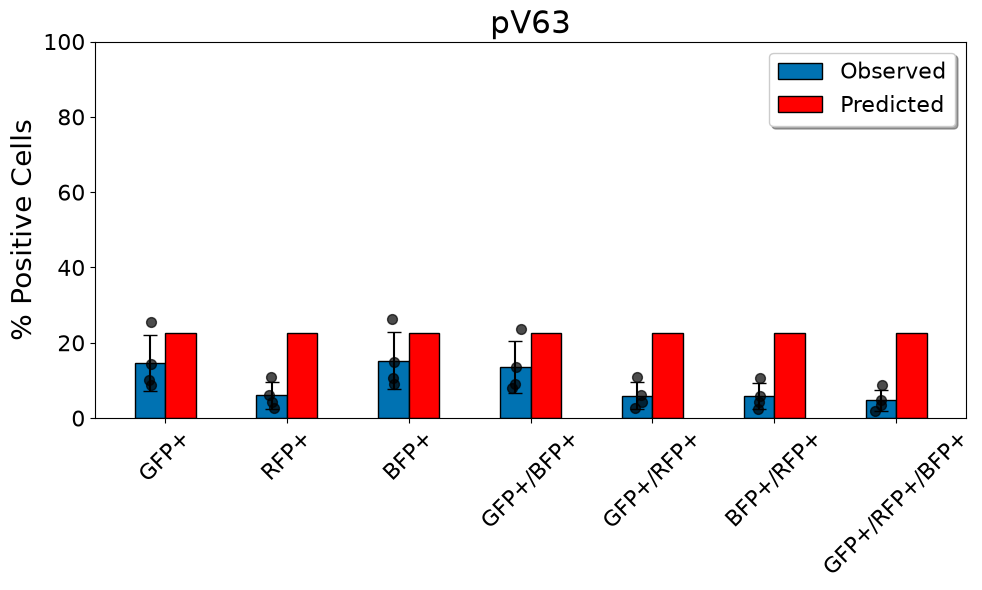

In [103]:
labels = ["GFP+", "RFP+", "BFP+", "GFP+/BFP+", "GFP+/RFP+", "BFP+/RFP+", "GFP+/RFP+/BFP+"]
x = np.arange(len(labels))
width =  0.25

for i in range(len(pred_out)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Bars
    ax.bar(x - width/2, data_avg[i] * 100, width=width, yerr=data_ci[i] * 100, color='#0072B2', edgecolor='black', label='Observed', capsize=5)
    ax.bar(x + width/2, pred_out[i] * 100, width=width, color='red', edgecolor='black', label='Predicted')
    
    for j in range(len(x)):
        x_jitter = np.random.normal(loc=x[j] - width/2, scale=0.02, size=len(data_plot[i].iloc[:,j]))
        ax.scatter(x_jitter, data_plot[i].iloc[:,j] * 100, color='black', alpha=0.7, s=50, zorder=10)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, rotation=45)
    ax.set_ylabel('% Positive Cells', fontsize=20)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_title(f'{plasmids[i]}', fontsize=22)
    ax.legend(loc='best', fontsize=16, frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f"Figures/Fig5/data_{plasmids[i]}.svg")
    plt.show()


In [104]:
two_pos_1 = data[[len(PLASMID_FLUORES[x]) == 2 for x in list(data.iloc[:,-1])]].iloc[:, 5]
all_pos_1 = data[[len(PLASMID_FLUORES[x]) > 2 for x in list(data.iloc[:,-1])]].iloc[:, 8]

df = pd.read_csv("Folder1-Flow_Cytometry_Data/20250312_GBR_Pre-Post-Mixing_Default Unmixed Worksheet.csv", index_col=0)
df = df[[
    "All Events Count", "Cell Population Count", "Green+ Count", "mCYRFP1+ Count", "Blue+ Count",
    "GFP-BFP+ Count", "GFP-RFP+ Count", "BFP-RFP+ Count", "All+ Count"
]]
df.columns = ["Events", "Cell Population", "GFP+", "RFP+", "BFP+", "GFP_BFP+", "GFP_RFP+", "BFP_RFP+", "All+"]
for col in ["GFP+", "RFP+", "BFP+", "GFP_BFP+", "GFP_RFP+", "BFP_RFP+", "All+"]:
    df[col] = df[col] / df["Cell Population"]
all_df = df[["All" in x for x in df.index]]
gb_df = df[["GFP+BFP" in x for x in df.index]]
gb_df = gb_df.iloc[:,5]
all_df = all_df.iloc[:,8]



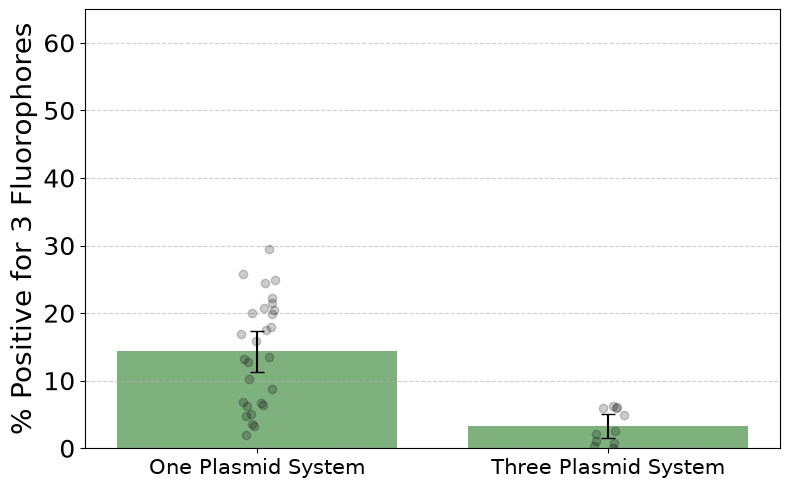

In [105]:
datasets = {
    "One Plasmid System": all_pos_1,
    "Three Plasmid System": all_df
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)

    raw_data.append(data)

x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))

yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

for i, values in enumerate([all_pos_1,all_df]):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(datasets.keys())
ax.set_ylabel('% Positive for 3 Fluorophores', fontsize=20)
#ax.set_title('Means with 95% CI and Raw Data Overlay')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
ax.set_ylim(0, 65)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()
plt.savefig(f"Figures/Fig5/plas3_vs1.svg")
plt.show()

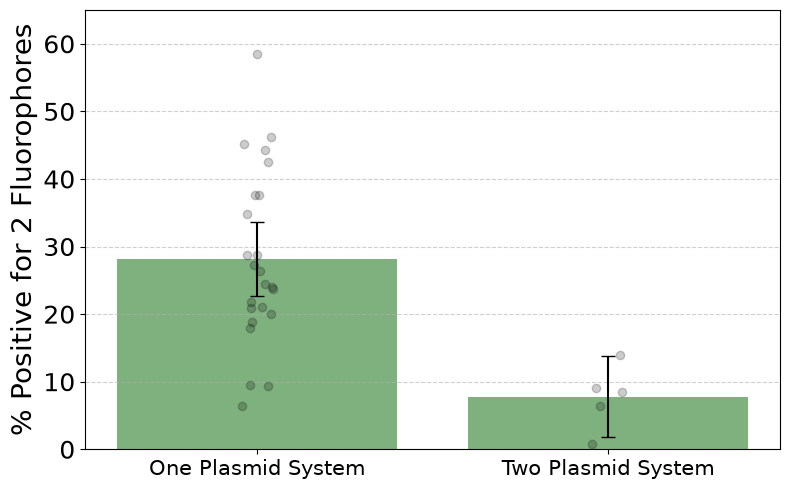

In [106]:
datasets = {
    "One Plasmid System": two_pos_1,
    "Two Plasmid System": gb_df,
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)

# Plotting
x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))

# CI error bars
yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

# Plot bars with CI
ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

# Overlay raw data
for i, values in enumerate(raw_data):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)
    
ax.set_xticks(x)
ax.set_ylabel('% Positive for 2 Fluorophores', fontsize=20)
#ax.set_title('Means with 95% CI and Raw Data Overlay')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
ax.set_ylim(0, 65)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()
plt.savefig(f"Figures/Fig5/plas2_vs1.svg")
plt.show()

In [111]:
u_stat, p_val = stats.mannwhitneyu(two_pos_1, gb_df, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 114.000, p = 0.00048840


In [112]:
u_stat, p_val = stats.mannwhitneyu(all_pos_1, all_df, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 281.000, p = 0.00007881


In [109]:
IRES = two_pos_1[np.array(["pV43" in x for x in two_pos_1.index]) + np.array(["pV44" in x for x in two_pos_1.index])]
link = np.array(["pV39" in x for x in two_pos_1.index])
link += np.array(["pV40" in x for x in two_pos_1.index])
link += np.array(["pV41" in x for x in two_pos_1.index])
link += np.array(["pV42" in x for x in two_pos_1.index])
link = two_pos_1[link]
u_stat, p_val = stats.mannwhitneyu(link, IRES, alternative="two-sided")
print(f"MWU-test: U = {u_stat:.3f}, p = {p_val:.8f}")


MWU-test: U = 109.000, p = 0.00450868


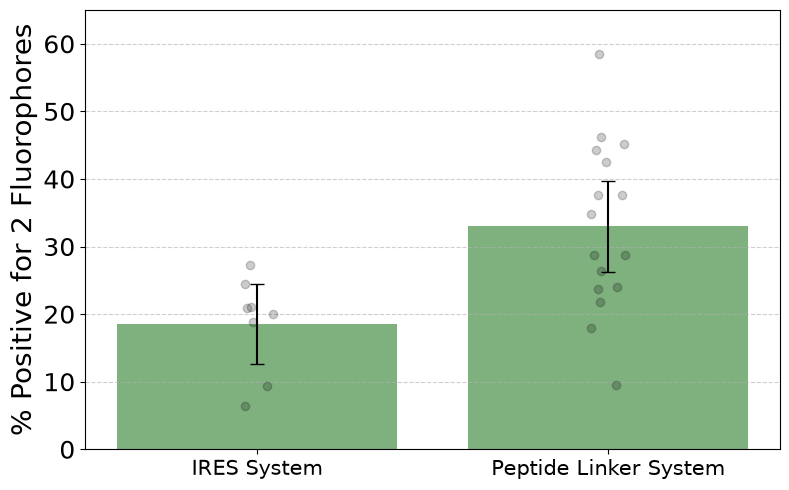

In [110]:
datasets = {
    "IRES System": IRES,
    "Peptide Linker System": link,
}

means = []
ci_lowers = []
ci_uppers = []
raw_data = []

for name, data in datasets.items():
    mean = np.mean(data)
    std_err = stats.sem(data)
    n = len(data)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_lower = mean - t_crit * std_err
    ci_upper = mean + t_crit * std_err

    means.append(mean)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    raw_data.append(data)


x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 5))


yerr = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

ax.bar(x,  np.array(means) * 100, yerr=np.array(yerr) * 100, capsize=5, color='darkgreen', alpha=0.5)

for i, values in enumerate(raw_data):
    ax.scatter(np.full_like(values, i, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(values)), values * 100,
               color='black', alpha=0.2, zorder=3)
    
ax.set_xticks(x)
ax.set_ylabel('% Positive for 2 Fluorophores', fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
ax.set_ylim(0, 65)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(datasets.keys(), fontsize=15)
plt.tight_layout()
plt.savefig(f"Figures/Fig5/IRES_vs_Link.svg")
plt.show()